In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

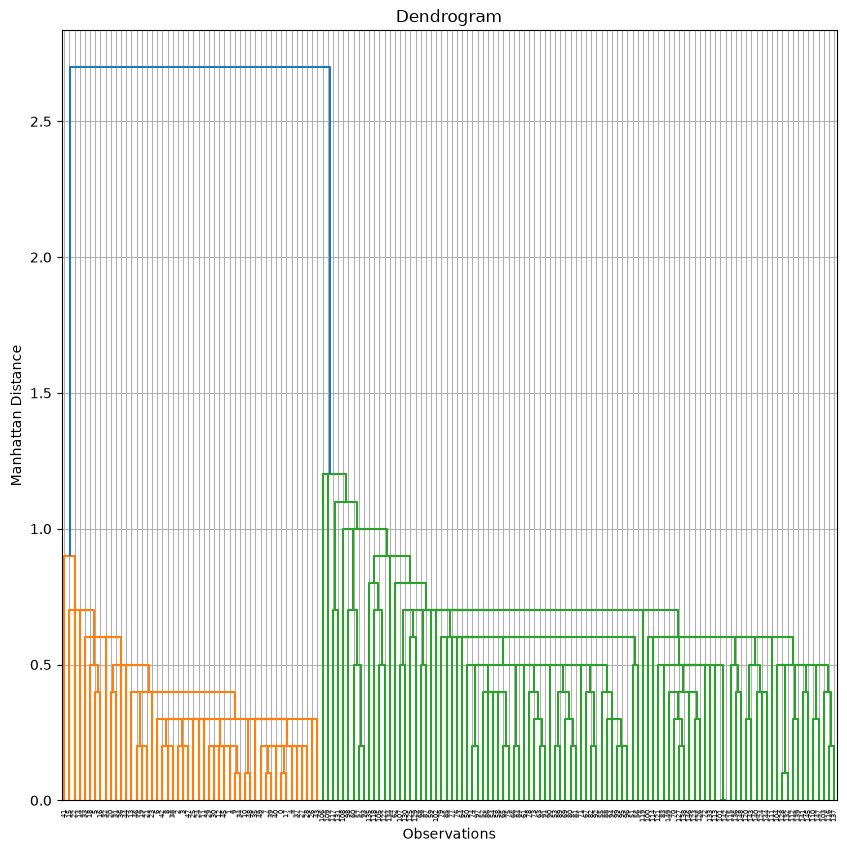

In [ ]:

df = pd.read_csv("iris_with_species.csv")


X = df.iloc[:, :-1]

plt.figure(figsize=(10,10))

dendrogram(
    linkage(
        X,
        method='single',
        metric='cityblock' 
    )
)

plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Manhattan Distance")
plt.grid(True)
plt.show()

In [6]:

hc = AgglomerativeClustering(
    n_clusters=2,
    metric='manhattan',
    linkage='single'
)

df['Cluster'] = hc.fit_predict(X)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1


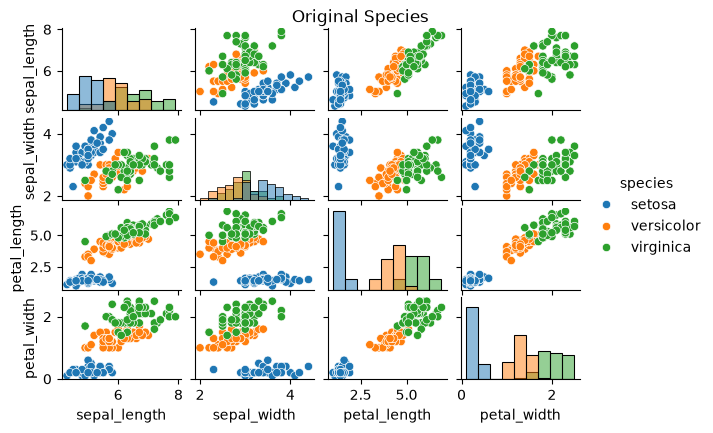

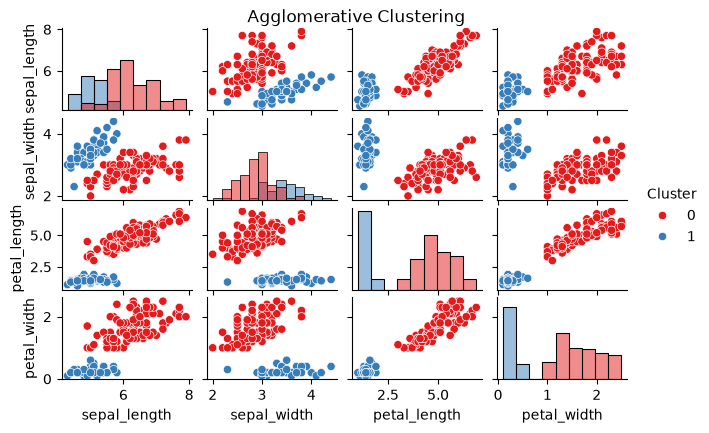

Cluster      0   1
species           
setosa       0  50
versicolor  50   0
virginica   50   0


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns


g1 = sns.pairplot(
    df,
    vars=['sepal_length',
          'sepal_width',
          'petal_length',
          'petal_width'],
    hue='species',
    diag_kind='hist',
    height=1.5
)

g1.fig.set_size_inches(7,4)
g1.fig.suptitle("Original Species", y=1.02)

plt.show()

# =========================
# Agglomerative Cluster Pairplot
# =========================
g2 = sns.pairplot(
    df,
    vars=['sepal_length',
          'sepal_width',
          'petal_length',
          'petal_width'],
    hue='Cluster',
    palette='Set1',
    diag_kind='hist',
    height=1.5
)

g2.fig.set_size_inches(7,4)
g2.fig.suptitle("Agglomerative Clustering", y=1.02)

plt.show()

# =========================
# Comparison Table
# =========================
print(pd.crosstab(df['species'], df['Cluster']))